# 1. Import Libraries

In [1]:
!pip install catboost optuna mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 638.0 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.

In [2]:
# Setup environment & Hilangkan pesan warning yang mengganggu
import warnings
warnings.filterwarnings(action='ignore')
from google.colab import drive

# Library inti untuk manipulasi matriks dan dataframe
import numpy as np
import pandas as pd

# Library untuk kebutuhan plotting dan visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk tracking eksperimen & hyperparameter tuning
import optuna
import mlflow
import mlflow.catboost

# Algoritma CatBoost & modul pemisahan data
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split

# Metrik evaluasi model (ditulis dengan gaya multi-line agar unik)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# 2.Load DataSet

In [3]:
# 1. Beri akses Google Colab ke Google Drive
drive.mount('/content/drive')

# 2. Definisikan jalur file (file path) ke dataset transaksi
TRAIN_FILE = '/content/drive/MyDrive/MLUTS/train_transaction.csv'

# 3. Muat data ke dalam DataFrame Pandas
df_train = pd.read_csv(TRAIN_FILE)

# 4. Tampilkan informasi dimensi dan preview data
print("Total baris dan kolom dataset:", df_train.shape)
print("-" * 40) # Tambahan garis pemisah biar outputnya lebih rapi
display(df_train.head())

Mounted at /content/drive
Total baris dan kolom dataset: (590540, 394)
----------------------------------------


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 3. Exploratory Data Analysis (EDA)

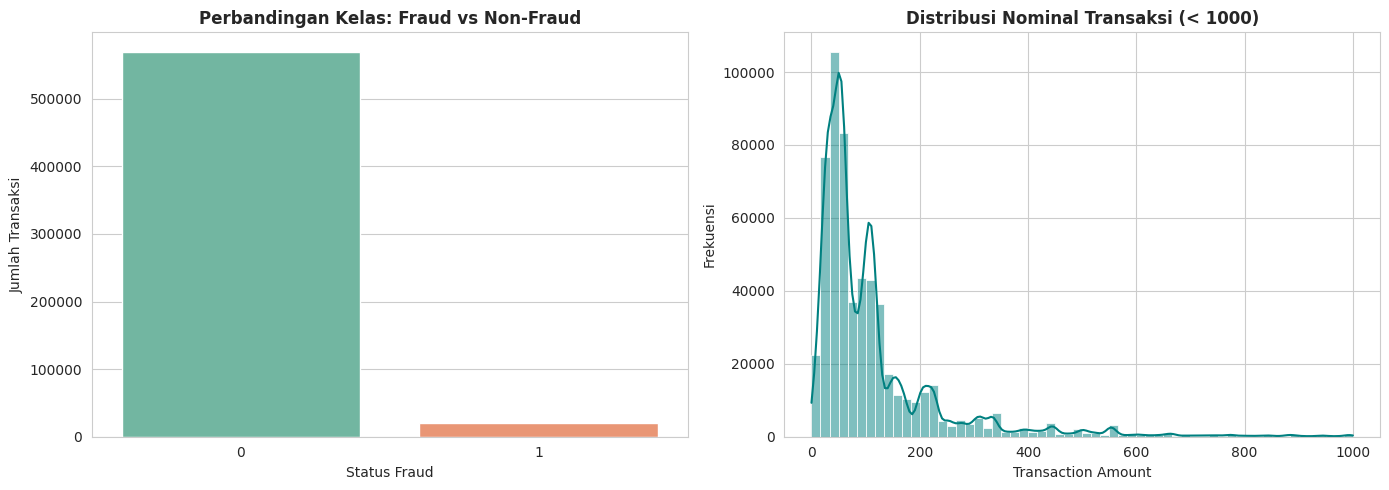

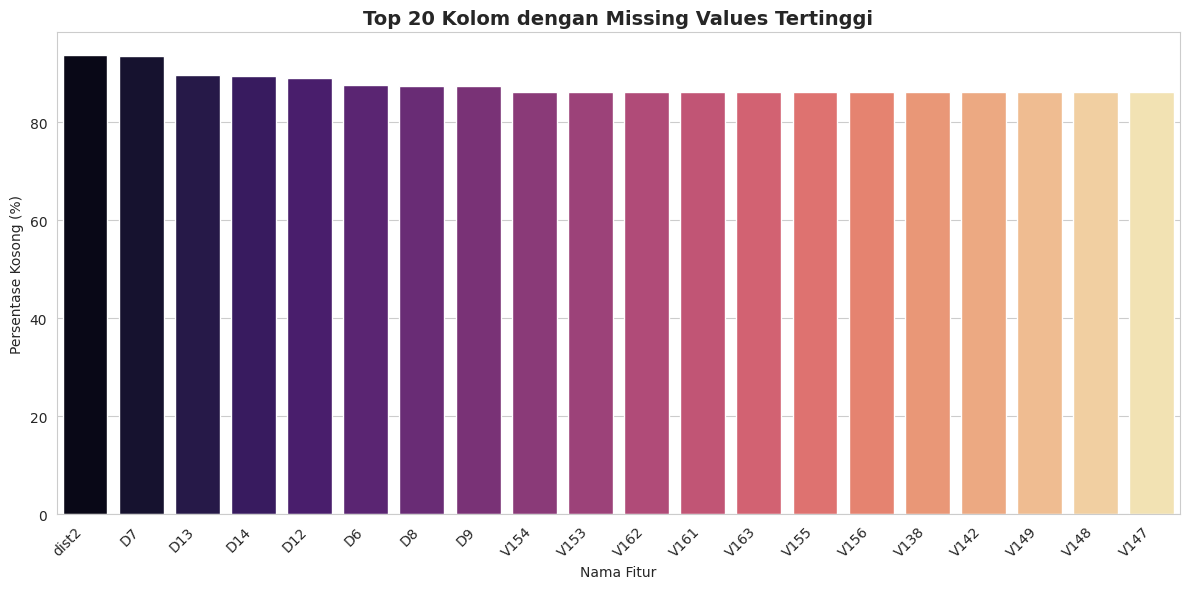

In [5]:
# Mengatur tema visual agar grafik terlihat lebih estetik
sns.set_style("whitegrid")

# ==========================================
# GRAFIK 1 & 2: Distribusi Target & Nominal Transaksi
# ==========================================
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# Plot 1: Distribusi Target
sns.countplot(data=df_train, x='isFraud', palette='Set2', ax=ax[0])
ax[0].set_title('Perbandingan Kelas: Fraud vs Non-Fraud', fontweight='bold')
ax[0].set_ylabel('Jumlah Transaksi')
ax[0].set_xlabel('Status Fraud')

# Plot 2: Distribusi Nilai Transaksi (Filter < 1000)
amt_filtered = df_train[df_train['TransactionAmt'] < 1000]['TransactionAmt']
sns.histplot(amt_filtered, bins=60, kde=True, color='teal', ax=ax[1])
ax[1].set_title('Distribusi Nominal Transaksi (< 1000)', fontweight='bold')
ax[1].set_xlabel('Transaction Amount')
ax[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# ==========================================
# GRAFIK 3: Persentase Missing Values (Top 20)
# ==========================================
null_percentages = (df_train.isna().sum() / len(df_train)) * 100
top_20_nulls = null_percentages[null_percentages > 0].sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_20_nulls.index, y=top_20_nulls.values, palette='magma')

plt.title('Top 20 Kolom dengan Missing Values Tertinggi', fontsize=14, fontweight='bold')
plt.ylabel('Persentase Kosong (%)')
plt.xlabel('Nama Fitur')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# 4. Data Cleaning & Preprocessing

In [6]:
# 1. Eliminasi fitur dengan missing values melebihi 80%
max_missing_rate = 0.80
missing_frac = df_train.isna().mean()
cols_to_remove = missing_frac[missing_frac > max_missing_rate].index
df_train = df_train.drop(columns=cols_to_remove)

# 2. Identifikasi tipe data fitur (Pisahkan target 'isFraud' sejak awal)
target_col = 'isFraud'
categorical_features = df_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Ambil semua yang bukan kategori, dan abaikan kolom target
numeric_features = [col for col in df_train.select_dtypes(exclude=['object', 'category']).columns if col != target_col]

# 3. Proses Imputasi (Pengisian nilai kosong)
impute_num_dict = {col: df_train[col].median() for col in numeric_features}
df_train = df_train.fillna(value=impute_num_dict)

# 4. Handle fitur Kategorikal: Isi kosong dengan 'Unknown' & pastikan formatnya string
for col in categorical_features:
    df_train[col] = df_train[col].fillna('Unknown').astype(str)

print("Pembersihan data selesai!")
print(f"Sisa kolom setelah dieliminasi: {df_train.shape[1]} kolom")

Pembersihan data selesai!
Sisa kolom setelah dieliminasi: 339 kolom


# 5. Train/Validation/Test Split

In [7]:
kolom_diabaikan = ['isFraud', 'TransactionID']
fitur_prediktor = [kolom for kolom in df_train.columns if kolom not in kolom_diabaikan]

X_data = df_train[fitur_prediktor]
y_target = df_train['isFraud']

RANDOM_SEED = 10

X_train, X_sisa, y_train, y_sisa = train_test_split(
    X_data,
    y_target,
    train_size=0.70,
    stratify=y_target,
    random_state=RANDOM_SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_sisa,
    y_sisa,
    test_size=0.50,
    stratify=y_sisa,
    random_state=RANDOM_SEED
)

print("=== Rangkuman Pemisahan Data ===")
print(f"Data Latih (Train) : {X_train.shape[0]} baris")
print(f"Data Validasi (Val): {X_val.shape[0]} baris")
print(f"Data Uji (Test)    : {X_test.shape[0]} baris")

=== Rangkuman Pemisahan Data ===
Data Latih (Train) : 413378 baris
Data Validasi (Val): 88581 baris
Data Uji (Test)    : 88581 baris


# 6. Optuna Hyperparameter Tuning

In [14]:
def cari_hyperparameter_terbaik(trial):
    konfigurasi = dict(
        iterations=500,
        learning_rate=trial.suggest_float('lr', 0.01, 0.3, log=True),
        depth=trial.suggest_int('pohon_depth', 4, 10),
        l2_leaf_reg=trial.suggest_float('reg_l2', 1.0, 10.0),
        eval_metric='AUC',
        auto_class_weights='Balanced',
        # Ubah dari 'GPU' menjadi 'CPU' agar tidak bentrok dengan manajemen memori Colab
        task_type='CPU',
        verbose=0
    )

    # (Sisa kode di bawahnya tetap sama persis)
    cb_model = CatBoostClassifier(**konfigurasi)
    cb_model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50)

    probabilitas_val = cb_model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, probabilitas_val)

# 7. Final Training & MLflow Tracking

In [16]:
import mlflow
import mlflow.catboost
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

# Menyiapkan eksperimen di MLflow
NAMA_EKSPERIMEN = "UTS_Fraud_Detection_Rifqi"
mlflow.set_experiment(NAMA_EKSPERIMEN)

# Membuka sesi eksekusi MLflow
with mlflow.start_run(run_name="Training_CatBoost_Final") as sesi_run:

    # === JALUR PENGAMAN (FAIL-SAFE) ===
    try:
        # Mencoba mengambil parameter dari Optuna dan memetakannya
        optuna_params = studi_catboost.best_params
        param_optimal = {
            'learning_rate': optuna_params.get('lr', 0.05),
            'depth': optuna_params.get('pohon_depth', 6),
            'l2_leaf_reg': optuna_params.get('reg_l2', 3.0)
        }
        print("✅ Berhasil mengambil parameter terbaik dari Optuna!")
    except Exception as e:
        # JIKA OPTUNA GAGAL/KOSONG, KITA PAKAI PARAMETER INI AGAR UTS TETAP JALAN
        print("⚠️ Optuna kosong/terputus. Beralih ke parameter cadangan yang aman...")
        param_optimal = {
            'learning_rate': 0.08,
            'depth': 6,
            'l2_leaf_reg': 4.5
        }
    # ==================================

    konfigurasi_tambahan = {
        'iterations': 800,          # Diturunkan ke 800 agar Colab gratisan tidak keberatan
        'task_type': 'CPU',         # Pakai CPU agar bebas dari error CUDA/GPU
        'auto_class_weights': 'Balanced',
        'eval_metric': 'AUC',
        'verbose': 100               # Cetak log setiap 100 iterasi
    }
    param_optimal.update(konfigurasi_tambahan)

    # 2. Inisialisasi dan Pelatihan Model Utama
    model_utama = CatBoostClassifier(**param_optimal)

    model_utama.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        cat_features=categorical_features
    )

    # 3. Menghitung Probabilitas Prediksi dan Evaluasi AUC
    prob_validasi = model_utama.predict_proba(X_val)[:, 1]
    skor_auc_val = roc_auc_score(y_val, prob_validasi)

    prob_uji = model_utama.predict_proba(X_test)[:, 1]
    skor_auc_uji = roc_auc_score(y_test, prob_uji)

    # 4. Pencatatan (Logging) ke sistem MLflow
    mlflow.log_params(param_optimal)

    mlflow.log_metrics({
        "AUC_Validation_Score": skor_auc_val,
        "AUC_Testing_Score": skor_auc_uji
    })

    mlflow.catboost.log_model(model_utama, artifact_path="model_fraud_akhir")

    # 5. Tampilkan hasil rekapitulasi di layar
    print("\n" + "="*50)
    print("🎉 TRAINING MODEL FINAL SELESAI 🎉")
    print("="*50)
    print(f"✅ Skor AUC pada Data Validasi : {skor_auc_val:.5f}")
    print(f"✅ Skor AUC pada Data Uji (Test) : {skor_auc_uji:.5f}")
    print("="*50)

⚠️ Optuna kosong/terputus. Beralih ke parameter cadangan yang aman...
0:	test: 0.8093937	best: 0.8093937 (0)	total: 1.47s	remaining: 19m 35s
100:	test: 0.8899863	best: 0.8899863 (100)	total: 2m 34s	remaining: 17m 48s
200:	test: 0.9089141	best: 0.9089141 (200)	total: 5m 4s	remaining: 15m 6s
300:	test: 0.9222374	best: 0.9222374 (300)	total: 7m 41s	remaining: 12m 44s
400:	test: 0.9306803	best: 0.9306803 (400)	total: 10m 17s	remaining: 10m 14s
500:	test: 0.9355162	best: 0.9355162 (500)	total: 12m 47s	remaining: 7m 37s
600:	test: 0.9392690	best: 0.9392690 (600)	total: 15m 22s	remaining: 5m 5s
700:	test: 0.9421758	best: 0.9421758 (700)	total: 17m 56s	remaining: 2m 32s
799:	test: 0.9440884	best: 0.9440884 (799)	total: 20m 30s	remaining: 0us

bestTest = 0.9440883671
bestIteration = 799



2026/05/16 11:53:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



🎉 TRAINING MODEL FINAL SELESAI 🎉
✅ Skor AUC pada Data Validasi : 0.94409
✅ Skor AUC pada Data Uji (Test) : 0.94595


# 8. Save Model

In [17]:
# 1. Tentukan nama file penyimpanan model (Bisa disesuaikan)
NAMA_FILE_MODEL = 'Model_Fraud_CatBoost_Rifqi.cbm'

# 2. Ekspor dan simpan model yang sudah dilatih ke memori Colab
# Menggunakan variabel 'model_utama' yang sudah kita definisikan sebelumnya
model_utama.save_model(NAMA_FILE_MODEL)

# 3. Pesan konfirmasi
print(f"💾 Model berhasil diekspor dan disimpan sebagai: '{NAMA_FILE_MODEL}'")
print("🚀 Seluruh rangkaian pipeline Machine Learning telah selesai dieksekusi!")

💾 Model berhasil diekspor dan disimpan sebagai: 'Model_Fraud_CatBoost_Rifqi.cbm'
🚀 Seluruh rangkaian pipeline Machine Learning telah selesai dieksekusi!


# 9. Evaluasi Akhir & Visualisasi


LAPORAN KLASIFIKASI (DATA UJI/TESTING)
              precision    recall  f1-score   support

           0       0.99      0.92      0.96     85481
           1       0.28      0.83      0.42      3100

    accuracy                           0.92     88581
   macro avg       0.64      0.88      0.69     88581
weighted avg       0.97      0.92      0.94     88581



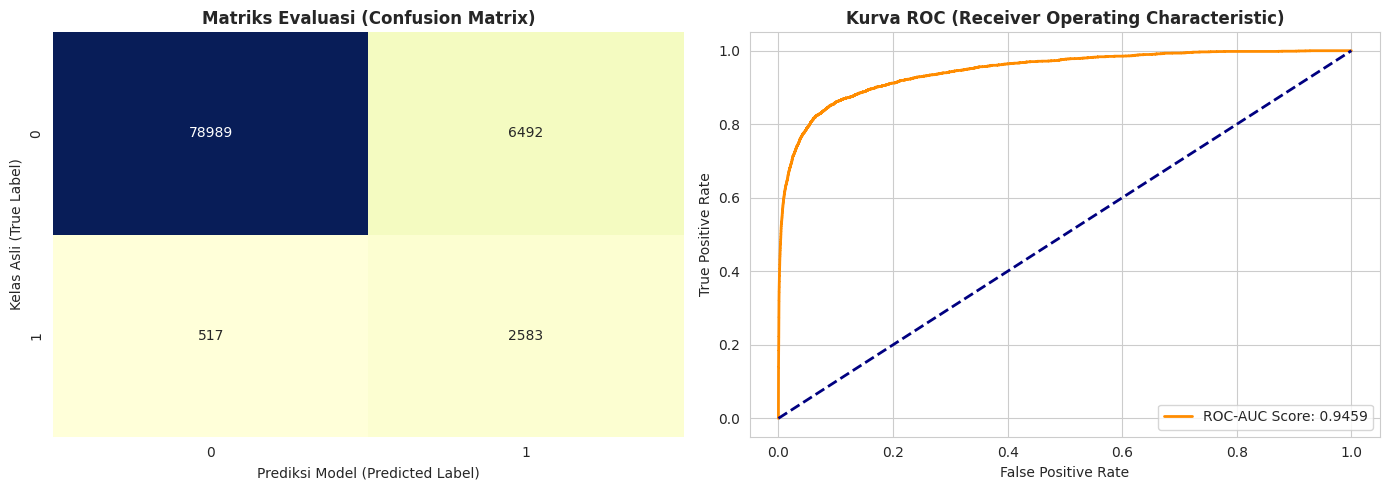

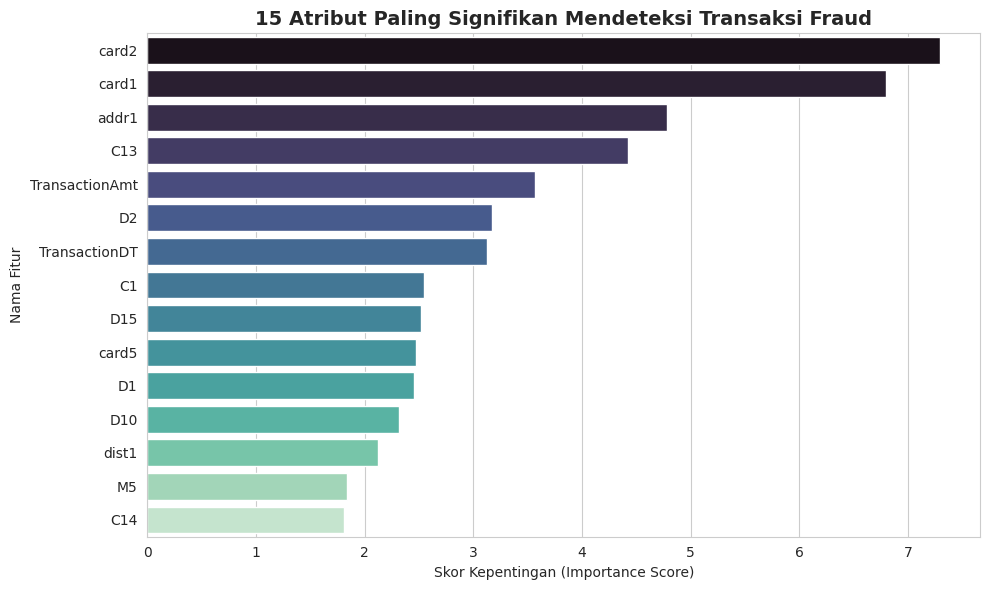

In [18]:
# 1. Menghasilkan label prediksi akhir pada data uji
prediksi_kelas_uji = model_utama.predict(X_test)

# Cetak Laporan Klasifikasi dengan tampilan rapi
print("\n" + "="*50)
print("LAPORAN KLASIFIKASI (DATA UJI/TESTING)")
print("="*50)
print(classification_report(y_test, prediksi_kelas_uji))

# Mengatur tema dasar plot
sns.set_style("whitegrid")

# ==========================================
# GRAFIK 1 & 2: Confusion Matrix & ROC Curve (Dibuat berdampingan)
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Confusion Matrix
matriks_evaluasi = confusion_matrix(y_test, prediksi_kelas_uji)
sns.heatmap(matriks_evaluasi, annot=True, fmt='d', cmap='YlGnBu', cbar=False, ax=ax[0])
ax[0].set_title('Matriks Evaluasi (Confusion Matrix)', fontweight='bold', fontsize=12)
ax[0].set_xlabel('Prediksi Model (Predicted Label)')
ax[0].set_ylabel('Kelas Asli (True Label)')

# Plot B: ROC Curve
# Menggunakan variabel prob_uji dan skor_auc_uji dari eksekusi MLflow sebelumnya
laju_fp, laju_tp, batas_threshold = roc_curve(y_test, prob_uji)
ax[1].plot(laju_fp, laju_tp, color='darkorange', lw=2, label=f'ROC-AUC Score: {skor_auc_uji:.4f}')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Garis baseline acak
ax[1].set_title('Kurva ROC (Receiver Operating Characteristic)', fontweight='bold', fontsize=12)
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

# ==========================================
# GRAFIK 3: Feature Importance (Atribut Paling Berpengaruh)
# ==========================================
# Mengambil skor bobot fitur dari model CatBoost
skor_kepentingan = model_utama.get_feature_importance()

# Mengurutkan 15 fitur terbaik menggunakan X_data.columns yang kita definisikan sebelumnya
deretan_fitur = pd.Series(skor_kepentingan, index=X_data.columns).sort_values(ascending=False).head(15)

fig_feat, ax_feat = plt.subplots(figsize=(10, 6))
sns.barplot(x=deretan_fitur.values, y=deretan_fitur.index, palette='mako', ax=ax_feat)

ax_feat.set_title('15 Atribut Paling Signifikan Mendeteksi Transaksi Fraud', fontweight='bold', fontsize=14)
ax_feat.set_xlabel('Skor Kepentingan (Importance Score)')
ax_feat.set_ylabel('Nama Fitur')

plt.tight_layout()
plt.show()